# Correcting a Sharpe ratio for the search that found it

**Docker image**: `ml4t`

**Book Reference**: Chapter 16, §16.7 - strategy-level overfitting control.

This notebook demonstrates comprehensive **backtest validation using the Deflated Sharpe Ratio (DSR)** from `ml4t-diagnostic`.

## What the corrections do

1. **Selection Bias Correction**: Adjust for multiple strategy testing
2. **Non-Normality Adjustments**: Account for skewness and kurtosis
3. **Probabilistic Interpretation**: One-sided evidence against a selection benchmark
4. **Practical Thresholds**: When is a Sharpe ratio statistically significant?

## Why a selected Sharpe needs a different benchmark

When we test N strategies and keep the largest observed Sharpe:
- **Expected max Sharpe under null**: E[max(SR₁,...,SRₙ)] ≈ √(2 log N) × σ_SR
- **A selected Sharpe can be misleading**: Its null benchmark rises with the trial count
- **DSR corrects**: Tests the observed Sharpe against a trial-adjusted benchmark

## References

- Bailey, D.H. & López de Prado, M. (2014). "The Deflated Sharpe Ratio"
- López de Prado, M. (2018). "Advances in Financial Machine Learning", Ch. 14

In [1]:
"""Validate Sharpe-ratio corrections for selection bias and non-normal returns."""

from itertools import combinations

import numpy as np
import plotly.graph_objects as go
import polars as pl

# ml4t-diagnostic
from ml4t.diagnostic.evaluation.stats import (
    compute_pbo,
    deflated_sharpe_ratio_from_statistics,
    rademacher_complexity,
    ras_sharpe_adjustment,
)
from plotly.subplots import make_subplots
from scipy import stats

from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging

In [2]:
# Production defaults - Papermill injects overrides after this cell
N_SIMULATIONS = 10000
NULL_STRATEGIES = 100
NULL_PERIODS = 252
SELECTED_SHARPE = 1.5
VARIANT_COUNT = 30
VARIANT_TRUE_SHARPE = 0.5
VARIANT_PERIODS = 504
NONNORMAL_TRIALS = 50
SEED = 42

### What each setting decides

**Null universe.** How many strategies with no edge at all are simulated, and how long each
record is. The count decides how large the largest observed Sharpe becomes; the length decides
how noisy each individual estimate is. Both feed the correction the rest of the notebook applies.

**Selected Sharpe.** The Sharpe of the single strategy carried through sections 2 to 4. It is a
figure most people would call good, which is the point: the deflation is applied to something
that looks like a success.

**Variant sweep.** A second experiment in which every candidate has the *same* real edge, so that
the largest observed Sharpe among them is that edge plus the luck of being the largest. The
number of variants and the record length decide how much of the second part there is.

In [3]:
set_global_seeds(SEED)
rng = np.random.default_rng(SEED)
EULER_MASCHERONI = 0.5772156649

### The deflated Sharpe ratio, step by step

A self-contained DSR implementation for demonstrating the math
step by step. The production helper in `ml4t-diagnostic` is compared below.

In [4]:
def _expected_max_sharpe(variance_trials: float, n_trials: int) -> float:
    """Expected maximum trial Sharpe in its native sampling frequency."""
    if n_trials <= 1 or variance_trials <= 0:
        return 0.0
    z1 = stats.norm.ppf(1.0 - (1.0 / n_trials))
    z2 = stats.norm.ppf(1.0 - (np.exp(-1.0) / n_trials))
    weight = (1.0 - EULER_MASCHERONI) * z1 + EULER_MASCHERONI * z2
    return float(np.sqrt(variance_trials) * weight)

Format the DSR components on the annualized reporting scale.

In [5]:
def _format_dsr_result(
    probability: float,
    z_score: float,
    expected_max: float,
    annualizer: float,
    observed_sharpe: float,
    confidence_level: float,
) -> dict[str, float | bool]:
    """Expose DSR components on the annualized scale used by the notebook."""
    expected_max_annual = expected_max * annualizer
    return {
        "dsr": probability,
        "z_score": z_score,
        "p_value": 1.0 - probability,
        "expected_max_sharpe": expected_max_annual,
        "adjusted_sharpe": observed_sharpe - expected_max_annual,
        "is_significant": probability >= confidence_level,
    }

Compute the deflated Sharpe ratio from annualized inputs and native observations.

In [6]:
def deflated_sharpe_ratio(
    observed_sharpe: float,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    n_samples: int = 252,
    n_trials: int = 1,
    variance_trials: float = 0.0,
    confidence_level: float = 0.95,
    return_format: str = "probability",
    return_components: bool = False,
    periods_per_year: int = 252,
) -> float | dict[str, float | bool]:
    """Compute DSR from annualized Sharpe statistics and native observations."""
    annualizer = np.sqrt(periods_per_year)
    observed_native = observed_sharpe / annualizer
    variance_native = max(variance_trials, 0.0) / periods_per_year
    expected_max = _expected_max_sharpe(variance_native, n_trials)
    variance = 1.0 - skewness * observed_native + ((kurtosis - 1.0) / 4.0) * observed_native**2
    denominator = np.sqrt(max(variance, 1e-12))
    z_score = (observed_native - expected_max) * np.sqrt(max(n_samples - 1, 1)) / denominator
    probability = float(stats.norm.cdf(z_score))
    components = _format_dsr_result(
        probability, float(z_score), expected_max, annualizer, observed_sharpe, confidence_level
    )
    if return_components:
        return components
    if return_format == "probability":
        return probability
    if return_format == "zscore":
        return float(z_score)
    if return_format in {"adjusted_sharpe", "adjusted"}:
        return float(components["adjusted_sharpe"])
    if return_format == "p_value":
        return float(components["p_value"])
    raise ValueError(f"Unknown return_format: {return_format}")

### The same thing from the library

The implementation above shows the math explicitly. In practice (and in the
case study notebooks), we use `ml4t-diagnostic` directly. The library is not
a drop-in match for the bare formula above. It rescales the cross-trial Sharpe
variance with its finite-sample multiple-trial convention and evaluates the
non-normal variance at the adjusted benchmark. It also supports autocorrelation
and returns a minimum-track-record (MinTRL) diagnostic. The local helper uses
the observed Sharpe in the non-normal variance term to expose the paper's
equation directly.

In [7]:
check_sharpe, check_skew, check_kurt, check_n = 1.5, -0.3, 4.0, 252
check_trials, check_variance = 50, 0.5

local_probability = deflated_sharpe_ratio(
    observed_sharpe=check_sharpe,
    skewness=check_skew,
    kurtosis=check_kurt,
    n_samples=check_n,
    n_trials=check_trials,
    variance_trials=check_variance,
    return_format="probability",
)
library_result = deflated_sharpe_ratio_from_statistics(
    observed_sharpe=check_sharpe / np.sqrt(252),  # the library works at the native frequency
    n_samples=check_n,
    n_trials=check_trials,
    variance_trials=check_variance / 252,
    skewness=check_skew,
    excess_kurtosis=check_kurt - 3.0,
)

print(f"Local implementation:  {local_probability:.4f}")
print(f"ml4t-diagnostic:       {library_result.probability:.4f}")
print(f"Library minimum track record: {library_result.min_trl_years:.1f} years")
print(f"Library says the sample is adequate: {library_result.has_adequate_sample}")

Local implementation:  0.4572
ml4t-diagnostic:       0.4082
Library minimum track record: 1.2 years
Library says the sample is adequate: False


### The uncorrected version, for comparison

Local implementation used by validation examples in this notebook.

In [8]:
# Implement probabilistic_sharpe_ratio locally (not in ml4t-diagnostic)
def probabilistic_sharpe_ratio(
    observed_sr: float,
    benchmark_sr: float = 0.0,
    n_observations: int = 252,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    periods_per_year: int = 252,
) -> float:
    """Compute PSR from annualized Sharpes and native-frequency observations."""
    annualizer = np.sqrt(periods_per_year)
    observed_native = observed_sr / annualizer
    benchmark_native = benchmark_sr / annualizer
    variance = 1.0 - skewness * observed_native + ((kurtosis - 1.0) / 4.0) * observed_native**2
    se_sr = np.sqrt(max(variance, 1e-12) / max(n_observations - 1, 1))
    z = (observed_native - benchmark_native) / se_sr
    return float(stats.norm.cdf(z))

## 1. What the deflated Sharpe ratio adjusts for

The DSR adjusts an observed Sharpe ratio for:
1. **Number of trials (K)**: More strategies tested = higher expected max
2. **Non-normality**: Skewed/fat-tailed returns inflate Sharpe
3. **Variance of trials**: High variance among tested strategies

$$DSR = \Phi\!\left(\frac{(\widehat{SR}-SR_0^*)\sqrt{T-1}}
{\sqrt{1-\gamma_3\widehat{SR}+\frac{\gamma_4-1}{4}\widehat{SR}^{\,2}}}\right)$$

The Sharpe quantities in this expression use the return series' native
frequency. The helper accepts annualized Sharpes and converts them internally.

In [9]:
def simulate_null_universe(n_strategies: int, n_periods: int, daily_vol: float = 0.01) -> dict:
    """Sharpe ratios of strategies whose expected return is exactly zero."""
    draws = rng.normal(0, daily_vol, size=(n_strategies, n_periods))
    sharpes = draws.mean(axis=1) / draws.std(axis=1, ddof=1) * np.sqrt(252)
    return {
        "sharpes": sharpes,
        "mean_sharpe": float(sharpes.mean()),
        "max_sharpe": float(sharpes.max()),
        "min_sharpe": float(sharpes.min()),
        "variance_sharpe": float(sharpes.var(ddof=1)),
    }


results = simulate_null_universe(NULL_STRATEGIES, NULL_PERIODS)

# Two estimates of where the maximum of that many null Sharpes should land.
crude_expected_max = np.sqrt(252 / NULL_PERIODS) * np.sqrt(2 * np.log(NULL_STRATEGIES))
gumbel_expected_max = _expected_max_sharpe(
    results["variance_sharpe"] / 252, NULL_STRATEGIES
) * np.sqrt(252)

print(f"Strategies simulated, all with zero expected return: {NULL_STRATEGIES}")
print(f"Days per strategy: {NULL_PERIODS}")
print(f"Mean observed Sharpe:    {results['mean_sharpe']:.3f}")
print(f"Worst observed Sharpe:   {results['min_sharpe']:.3f}")
print(f"Best observed Sharpe:    {results['max_sharpe']:.3f}")
print(f"Variance across trials:  {results['variance_sharpe']:.3f}")
print(f"Expected best, sqrt(2 log N) approximation: {crude_expected_max:.3f}")
print(f"Expected best, extreme-value formula:       {gumbel_expected_max:.3f}")

Strategies simulated, all with zero expected return: 100
Days per strategy: 252
Mean observed Sharpe:    0.107
Worst observed Sharpe:   -2.578
Best observed Sharpe:    2.473
Variance across trials:  1.315
Expected best, sqrt(2 log N) approximation: 3.035
Expected best, extreme-value formula:       2.902


Two predictions are printed because they are different objects and the difference matters. The
$\sqrt{2\log N}$ expression is the familiar back-of-envelope bound, and it is a bound: it sits
above the expectation rather than on it. The extreme-value expression is the expected maximum,
and it is the one the deflated Sharpe ratio uses internally.

Both sit above the maximum this particular batch produced, which is the third thing worth
noticing. The largest of a hundred draws is itself a random variable with a wide distribution,
so a single batch landing below its own expectation is ordinary. The correction is built on the
expectation, not on what one batch happened to do.

The variance of Sharpe ratios across trials is printed for the same reason: it is an input to
the correction, not a description of the output. Its true value here is fixed by the record
length rather than by anything about the strategies - at a year of daily data it is close to one
- and the *measured* value across a hundred trials swings by a third of itself from one draw to
the next. Every section below feeds it the measured value rather than a nominal one, so the
correction that follows carries that noise too.

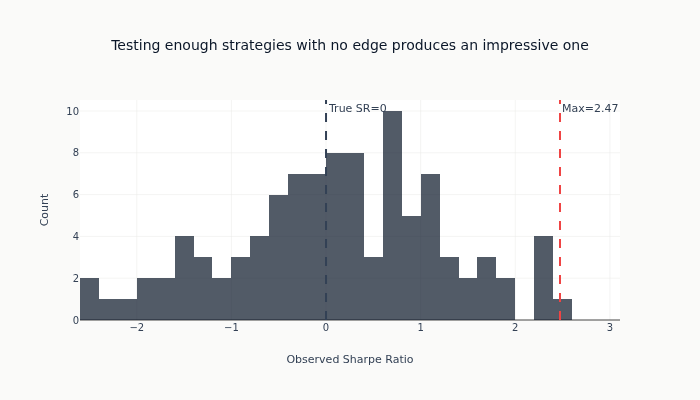

In [10]:
# Visualize the distribution
fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=results["sharpes"],
        nbinsx=30,
        name="Observed Sharpes",
        marker_color=COLORS["blue"],
        opacity=0.7,
    )
)

# Add markers
fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="True SR=0",
)
fig.add_vline(
    x=results["max_sharpe"],
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text=f"Max={results['max_sharpe']:.2f}",
)

fig.update_layout(
    title="Testing enough strategies with no edge produces an impressive one",
    xaxis_title="Observed Sharpe Ratio",
    yaxis_title="Count",
    height=400,
)
fig.show()

## 2. What the correction costs a good-looking strategy

Use `ml4t-diagnostic` to compute DSR with proper corrections.

In [11]:
# Generate a "selected" strategy with observed Sharpe = 1.5
n_periods = NULL_PERIODS
target_sharpe = SELECTED_SHARPE

# Create returns with target Sharpe
daily_vol = 0.01
daily_mean = (target_sharpe * daily_vol) / np.sqrt(252)
returns = rng.normal(daily_mean, daily_vol, n_periods)

# Calculate statistics
observed_sharpe = np.mean(returns) / np.std(returns, ddof=1) * np.sqrt(252)
skewness = stats.skew(returns)
kurtosis = stats.kurtosis(returns) + 3  # Excess to raw kurtosis

print(f"Observed Sharpe: {observed_sharpe:.3f}")
print(f"Skewness: {skewness:.3f}")
print(f"Excess Kurtosis: {kurtosis - 3:.3f}")

Observed Sharpe: 2.001
Skewness: 0.129
Excess Kurtosis: 0.344


In [12]:
trials_list = [1, 5, 10, 25, 50, 100, 200, 500]
dsr_results = []
variance_trials = results["variance_sharpe"]

for k in trials_list:
    # Compute DSR
    dsr_result = deflated_sharpe_ratio(
        observed_sharpe=observed_sharpe,
        skewness=skewness,
        kurtosis=kurtosis,
        n_samples=n_periods,
        n_trials=k,
        variance_trials=variance_trials,
        return_format="probability",
    )

    dsr_results.append({"n_trials": k, "dsr_probability": dsr_result})

dsr_df = pl.DataFrame(dsr_results)

**DSR vs number of trials** (multiple-testing haircut: same observed Sharpe,
more trials means a higher null bound and a lower DSR):

In [13]:
dsr_df

n_trials,dsr_probability
i64,f64
1,0.977471
5,0.737154
10,0.577664
25,0.386169
50,0.27097
100,0.183553
200,0.120663
500,0.066644


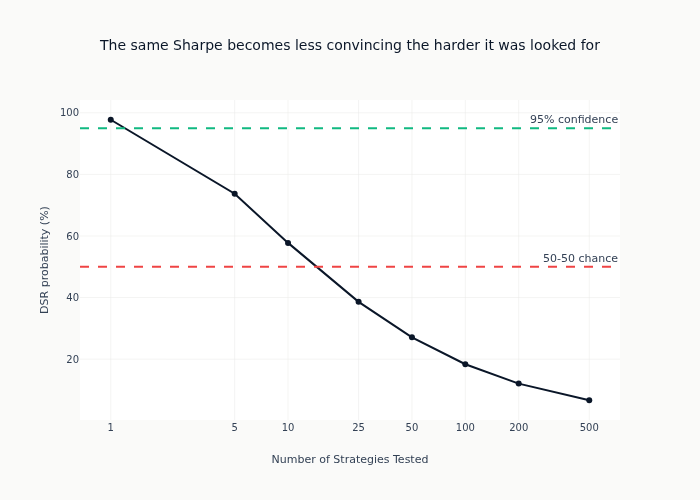

In [14]:
# Visualize DSR decay with number of trials
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=dsr_df.get_column("n_trials").to_list(),
        y=(dsr_df.get_column("dsr_probability") * 100).to_list(),
        mode="lines+markers",
        name="DSR Probability",
        line={"color": COLORS["blue"], "width": 2},
    )
)
fig.add_hline(
    y=95,
    line_dash="dash",
    line_color=COLORS["positive"],
    annotation_text="95% confidence",
)
fig.add_hline(
    y=50,
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text="50-50 chance",
)
fig.update_layout(
    title="The same Sharpe becomes less convincing the harder it was looked for",
    xaxis_title="Number of Strategies Tested",
    yaxis_title="DSR probability (%)",
    xaxis_type="log",
    height=500,
)
_n_trials_ticks = dsr_df.get_column("n_trials").to_list()
fig.update_xaxes(
    tickmode="array",
    tickvals=_n_trials_ticks,
    ticktext=[str(t) for t in _n_trials_ticks],
)
fig.show()

## 3. The same result in three units

The DSR function supports multiple output formats for different use cases.

In [15]:
k = 50
dsr_inputs = {
    "observed_sharpe": observed_sharpe,
    "skewness": skewness,
    "kurtosis": kurtosis,
    "n_samples": n_periods,
    "n_trials": k,
    "variance_trials": variance_trials,
}
dsr_prob = deflated_sharpe_ratio(**dsr_inputs, return_format="probability")
dsr_zscore = deflated_sharpe_ratio(**dsr_inputs, return_format="zscore")
dsr_adjusted = deflated_sharpe_ratio(**dsr_inputs, return_format="adjusted")

print("=" * 60)
print(f"DSR RESULTS (Observed SR={observed_sharpe:.3f}, K={k} trials)")
print("=" * 60)
print(f"\nProbability above the selection benchmark: {dsr_prob:.1%}")
print(f"Z-score: {dsr_zscore:.3f}")
print(f"Adjusted Sharpe: {dsr_adjusted:.3f}")

DSR RESULTS (Observed SR=2.001, K=50 trials)

Probability above the selection benchmark: 27.1%
Z-score: -0.610
Adjusted Sharpe: -0.609


## 4. How much skewness and kurtosis matter

Skewness and kurtosis significantly affect Sharpe ratio reliability.

In [16]:
# Analyze impact of non-normality
skewness_values = [-1.5, -0.5, 0, 0.5, 1.5]
kurtosis_values = [3, 5, 7, 10]  # Raw kurtosis (normal = 3)

results_matrix = []

for skew in skewness_values:
    for kurt in kurtosis_values:
        dsr = deflated_sharpe_ratio(
            observed_sharpe=SELECTED_SHARPE,
            skewness=skew,
            kurtosis=kurt,
            n_samples=NULL_PERIODS,
            n_trials=NONNORMAL_TRIALS,
            variance_trials=variance_trials,
            return_format="probability",
        )
        results_matrix.append(
            {
                "skewness": skew,
                "kurtosis": kurt,
                "excess_kurtosis": kurt - 3,
                "dsr_probability": dsr,
            }
        )

nonnorm_df = pl.DataFrame(results_matrix)

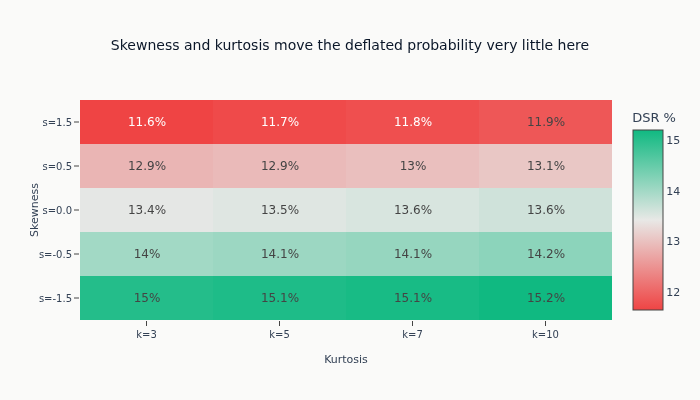

In [17]:
# Create heatmap - pivot the data
pivot = nonnorm_df.pivot(on="kurtosis", index="skewness", values="dsr_probability")
skew_col = pivot.get_column("skewness").to_list()
kurt_cols = [c for c in pivot.columns if c != "skewness"]
z_values = pivot.select(kurt_cols).to_numpy() * 100

fig = go.Figure(
    data=go.Heatmap(
        z=z_values,
        x=[f"k={k}" for k in kurt_cols],
        y=[f"s={s:.1f}" for s in skew_col],
        colorscale=ml4t_diverging(),
        colorbar={"title": "DSR %"},
        text=np.round(z_values, 1),
        texttemplate="%{text}%",
        textfont={"size": 12},
    )
)

fig.update_layout(
    title="Skewness and kurtosis move the deflated probability very little here",
    xaxis_title="Kurtosis",
    yaxis_title="Skewness",
    height=400,
)
fig.show()

## 5. Selecting the largest Sharpe from variants that all work equally well

Section 1 showed selection acting on a universe where nothing works. This one is the harder and
more realistic case: every candidate has the *same* real edge, so there is nothing to discover by
ranking them. Whatever separates the largest observed Sharpe from the others is entirely luck,
and the correction has to remove exactly that much.

The returns are parametric draws, not a strategy run on prices: no ETF data is loaded and no
signal is computed here. The real-data version of this sweep lives in the case studies.

In [18]:
# Generate 30 synthetic variants that share the same true Sharpe.
n_variants = VARIANT_COUNT
true_sharpe = VARIANT_TRUE_SHARPE
n_periods = VARIANT_PERIODS
daily_vol = 0.015
daily_mean = true_sharpe * daily_vol / np.sqrt(252)

variant_results = []
variant_returns = np.empty((n_periods, n_variants))

for i in range(n_variants):
    candidate_returns = rng.normal(daily_mean, daily_vol, n_periods)
    variant_returns[:, i] = candidate_returns
    obs_sharpe = candidate_returns.mean() / candidate_returns.std(ddof=1) * np.sqrt(252)
    variant_results.append(
        {
            "variant": i + 1,
            "observed_sharpe": obs_sharpe,
            "skewness": stats.skew(candidate_returns),
            "kurtosis": stats.kurtosis(candidate_returns) + 3,
        }
    )

variants_df = pl.DataFrame(variant_results)
best = variants_df.filter(pl.col("observed_sharpe") == pl.col("observed_sharpe").max()).row(
    0, named=True
)

print(f"Sampled {n_variants} synthetic strategy variants")
print(f"\nBest variant (#{int(best['variant'])}):")
print(f"  Observed Sharpe: {best['observed_sharpe']:.3f}")
print(f"  Skewness: {best['skewness']:.3f}")
print(f"  Kurtosis: {best['kurtosis']:.3f}")

Sampled 30 synthetic strategy variants

Best variant (#22):
  Observed Sharpe: 2.170
  Skewness: 0.021
  Kurtosis: 3.080


In [19]:
# Compute variance of Sharpe across variants
variance_across_variants = variants_df.get_column("observed_sharpe").var()

# Compute DSR for best variant
dsr_best = deflated_sharpe_ratio(
    observed_sharpe=best["observed_sharpe"],
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_samples=n_periods,
    n_trials=n_variants,
    variance_trials=variance_across_variants,
    return_format="probability",
)

# Also compute raw PSR (without multiple testing correction)
psr_best = probabilistic_sharpe_ratio(
    observed_sr=best["observed_sharpe"],
    benchmark_sr=0.0,
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_observations=n_periods,
)

print("=" * 60)
print("DSR ADJUSTMENT ON BEST-OF-30 SYNTHETIC VARIANTS")
print("=" * 60)
print(f"\nVariants sampled: {n_variants}")
print(f"Variance across variants: {variance_across_variants:.4f}")
print(f"\nBest variant Sharpe: {best['observed_sharpe']:.3f}")
print("\nWithout multiple-testing correction (PSR):")
print(f"  Probability SR > 0: {psr_best:.1%}")
print("\nWith multiple-testing correction (DSR):")
print(f"  Probability above selection benchmark: {dsr_best:.1%}")
print(f"\n{'SIGNIFICANT' if dsr_best > 0.95 else 'NOT SIGNIFICANT'} at 95% confidence")

DSR ADJUSTMENT ON BEST-OF-30 SYNTHETIC VARIANTS

Variants sampled: 30
Variance across variants: 0.6078

Best variant Sharpe: 2.170

Without multiple-testing correction (PSR):
  Probability SR > 0: 99.9%

With multiple-testing correction (DSR):
  Probability above selection benchmark: 78.2%

NOT SIGNIFICANT at 95% confidence


## 6. A second correction, with a different idea of the penalty

Both DSR and RAS address backtest overfitting, but from different perspectives:
- **DSR**: Multiple testing correction (how many strategies tested?)
- **RAS**: Complexity penalty (how readily the candidate return class fits random signs)

In [20]:
# Compute complexity from the same candidate return class selected above.
R_hat = rademacher_complexity(
    variant_returns,
    n_simulations=1000,
    random_state=SEED,
)

# Apply RAS adjustment (expects array input)
ras_adjusted = ras_sharpe_adjustment(
    observed_sharpe=np.array([best["observed_sharpe"]]),
    complexity=R_hat,
    n_samples=n_periods,
    n_strategies=n_variants,
    delta=0.05,
)[0]  # Get scalar result

# DSR adjusted Sharpe
dsr_adjusted_sharpe = deflated_sharpe_ratio(
    observed_sharpe=best["observed_sharpe"],
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_samples=n_periods,
    n_trials=n_variants,
    variance_trials=variance_across_variants,
    return_format="adjusted",
)

print("=" * 60)
print("DSR vs RAS COMPARISON")
print("=" * 60)
print(f"\nObserved Sharpe: {best['observed_sharpe']:.3f}")
print(f"\nDSR Adjusted Sharpe: {dsr_adjusted_sharpe:.3f}")
print(f"RAS Adjusted Sharpe: {ras_adjusted:.3f}")
print(f"\nRademacher Complexity: {R_hat:.4f}")
print("\nInterpretation:")
print(f"  DSR penalizes for {n_variants} trials tested")
print(f"  RAS penalizes the candidate return class (R={R_hat:.4f})")

DSR vs RAS COMPARISON

Observed Sharpe: 2.170

DSR Adjusted Sharpe: 0.553
RAS Adjusted Sharpe: 1.636

Rademacher Complexity: 0.0014

Interpretation:
  DSR penalizes for 30 trials tested
  RAS penalizes the candidate return class (R=0.0014)


In [21]:
# Visualize adjustments across range of observed Sharpes
observed_range = np.linspace(0.5, 2.5, 20)

dsr_adjusted_list = []
ras_adjusted_list = []

for sr in observed_range:
    dsr_adj = deflated_sharpe_ratio(
        observed_sharpe=sr,
        skewness=-0.3,
        kurtosis=4.0,
        n_samples=n_periods,
        n_trials=n_variants,
        variance_trials=variance_across_variants,
        return_format="adjusted",
    )

    ras_adj = ras_sharpe_adjustment(
        observed_sharpe=np.array([sr]),
        complexity=R_hat,
        n_samples=n_periods,
        n_strategies=n_variants,
        delta=0.05,
    )[0]

    dsr_adjusted_list.append(dsr_adj)
    ras_adjusted_list.append(ras_adj)

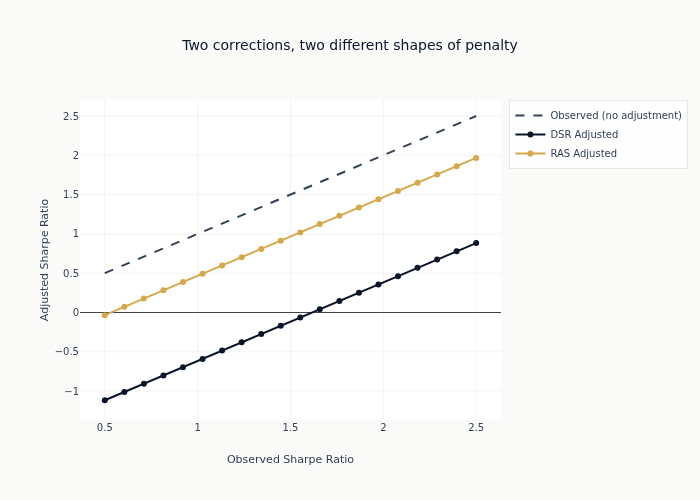

In [22]:
# Plot DSR vs RAS adjustments
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=observed_range,
        mode="lines",
        name="Observed (no adjustment)",
        line={"dash": "dash", "color": COLORS["neutral"]},
    )
)
fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=dsr_adjusted_list,
        mode="lines+markers",
        name="DSR Adjusted",
        line={"color": COLORS["blue"]},
    )
)
fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=ras_adjusted_list,
        mode="lines+markers",
        name="RAS Adjusted",
        line={"color": COLORS["amber"]},
    )
)

fig.update_layout(
    title="Two corrections, two different shapes of penalty",
    xaxis_title="Observed Sharpe Ratio",
    yaxis_title="Adjusted Sharpe Ratio",
    height=500,
)
fig.show()

## 7. Choosing between them, and what a threshold implies

### When each one applies

| Situation | Recommended Method |
|-----------|--------------------|
| Many strategy variants tested | DSR |
| Complex ML model | RAS |
| Parameter optimization | DSR |
| Feature selection | RAS |
| Both apply | Use both, report more conservative |

### What a strategy has to clear

The required observed Sharpe is not a universal lookup value. It depends on
sample length, trial dispersion, skewness, and kurtosis. The calculation below
holds those assumptions fixed and solves the threshold for each trial count.

In [23]:
# Compute minimum Sharpe for significance at different trial counts
trial_counts = [5, 10, 25, 50, 100, 200, 500]
min_sharpes = []

for k in trial_counts:
    # Binary search for minimum Sharpe that gives DSR > 0.95
    low, high = 0.5, 4.0

    while high - low > 0.01:
        mid = (low + high) / 2
        dsr = deflated_sharpe_ratio(
            observed_sharpe=mid,
            skewness=-0.3,
            kurtosis=4.0,
            n_samples=VARIANT_PERIODS,
            n_trials=k,
            variance_trials=variance_across_variants,
            return_format="probability",
        )

        if dsr < 0.95:
            low = mid
        else:
            high = mid

    min_sharpes.append({"n_trials": k, "min_sharpe_95": (low + high) / 2})

min_sharpe_df = pl.DataFrame(min_sharpes)

The observed Sharpe a strategy would need to clear the deflated threshold, at each trial count.
Read it before starting a search rather than after: it says what the search has to find.

In [24]:
min_sharpe_df

n_trials,min_sharpe_95
i64,f64
5,2.123535
10,2.431152
25,2.766113
50,2.984863
100,3.189941
200,3.374512
500,3.606934


## 8. Asking whether the selection itself was stable

PBO complements DSR with a *selection-process* question. After partitioning
observations into an even number of blocks, combinatorial symmetric
cross-validation (CSCV) assigns half the blocks to IS and the complement to
OOS. How often does the strategy selected in sample rank in the bottom half out of sample?

Each row of the input matrices must represent one complementary CSCV split,
and each cell must be computed from the corresponding strategy return series.
Independent random IS/OOS score matrices do not implement this mechanism.

We construct two diagnostic scenarios using real simulated return series:

1. **All-noise universe.** Every candidate has true SR = 0. Selection on the
   in-sample maximum is selection on noise.
2. **Mixed universe.** A handful of candidates have a real edge; the rest are
   noise. Stable candidates can retain an advantage in both IS and OOS.

In [25]:
PBO_OBSERVATIONS = 4800
N_BLOCKS = 10
N_STRATEGIES = 20
PBO_TRUE_SR_SIGNAL = 1.5
DSR_PASS_THRESHOLD = 0.95
PBO_REJECT_THRESHOLD = 0.25

Simulate candidate return histories for the DSR and PBO comparison.

In [26]:
def simulate_strategy_returns(
    true_sr_by_strategy: np.ndarray,
    n_observations: int,
    daily_vol: float = 0.01,
    seed: int = 0,
) -> np.ndarray:
    """Simulate one return history for every candidate strategy."""
    rng = np.random.default_rng(seed)
    daily_means = true_sr_by_strategy * daily_vol / np.sqrt(252)
    return rng.normal(
        loc=daily_means,
        scale=daily_vol,
        size=(n_observations, len(true_sr_by_strategy)),
    )

In [27]:
def _sharpe_from_moments(count: int, sums: np.ndarray, sums_sq: np.ndarray) -> np.ndarray:
    """Compute annualized sample Sharpes from sufficient statistics."""
    means = sums / count
    variances = np.maximum((sums_sq - sums**2 / count) / (count - 1), 1e-12)
    return means / np.sqrt(variances) * np.sqrt(252)

Construct complementary in-sample and out-of-sample CSCV Sharpe matrices.

In [28]:
def cscv_sharpe_matrices(
    strategy_returns: np.ndarray,
    n_blocks: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Build complementary IS/OOS Sharpe rows for every CSCV combination."""
    if n_blocks < 2 or n_blocks % 2:
        raise ValueError("n_blocks must be an even integer of at least 2")
    blocks = np.array_split(strategy_returns, n_blocks, axis=0)
    counts = np.array([len(block) for block in blocks])
    sums = np.stack([block.sum(axis=0) for block in blocks])
    sums_sq = np.stack([(block**2).sum(axis=0) for block in blocks])
    total_count, total_sums = counts.sum(), sums.sum(axis=0)
    total_sums_sq = sums_sq.sum(axis=0)
    split_indices = list(combinations(range(n_blocks), n_blocks // 2))
    is_sharpes = np.empty((len(split_indices), strategy_returns.shape[1]))
    oos_sharpes = np.empty_like(is_sharpes)
    for row, selected in enumerate(split_indices):
        selected = np.asarray(selected)
        is_count = int(counts[selected].sum())
        is_sums = sums[selected].sum(axis=0)
        is_sums_sq = sums_sq[selected].sum(axis=0)
        is_sharpes[row] = _sharpe_from_moments(is_count, is_sums, is_sums_sq)
        oos_sharpes[row] = _sharpe_from_moments(
            total_count - is_count, total_sums - is_sums, total_sums_sq - is_sums_sq
        )
    return is_sharpes, oos_sharpes

### When nothing works

Selection on the in-sample maximum is selection on noise. The output reports
the resulting rank-instability frequency for this simulated panel.

In [29]:
true_sr_noise = np.zeros(N_STRATEGIES)
noise_returns = simulate_strategy_returns(
    true_sr_noise,
    n_observations=PBO_OBSERVATIONS,
    seed=42,
)
is_noise, oos_noise = cscv_sharpe_matrices(noise_returns, N_BLOCKS)
pbo_noise = compute_pbo(is_performance=is_noise, oos_performance=oos_noise)
pbo_noise_dict = pbo_noise.to_dict() if hasattr(pbo_noise, "to_dict") else pbo_noise

print(
    f"All-noise PBO: {pbo_noise_dict['pbo']:.1%} "
    "(selection on noise has no persistent OOS advantage)"
)

All-noise PBO: 70.2% (selection on noise has no persistent OOS advantage)


### When something does

Hidden ground truth: strategies 0, 7, 14 have a stable positive expected
return; the rest are noise. The output measures the resulting PBO.

In [30]:
true_sr_mixed = np.zeros(N_STRATEGIES)
true_sr_mixed[[0, 7, 14]] = PBO_TRUE_SR_SIGNAL
mixed_returns = simulate_strategy_returns(
    true_sr_mixed,
    n_observations=PBO_OBSERVATIONS,
    seed=42,
)
is_mixed, oos_mixed = cscv_sharpe_matrices(mixed_returns, N_BLOCKS)
pbo_mixed = compute_pbo(is_performance=is_mixed, oos_performance=oos_mixed)
pbo_mixed_dict = pbo_mixed.to_dict() if hasattr(pbo_mixed, "to_dict") else pbo_mixed

print(
    f"Mixed-edge PBO: {pbo_mixed_dict['pbo']:.1%} "
    "(stable edge can persist across complementary samples)"
)

Mixed-edge PBO: 0.0% (stable edge can persist across complementary samples)


### The two side by side

The table below contrasts the two scenarios and shows whether adding stable
positive-mean candidates changes PBO for this draw.

In [31]:
# Headline scenario for the rest of the section / figure.
is_performance = is_mixed
oos_performance = oos_mixed
pbo_result = pbo_mixed
pbo_result_dict = pbo_mixed_dict
pbo_value = pbo_result_dict["pbo"]

pl.DataFrame(
    {
        "scenario": [
            "All noise (SR=0 for all)",
            f"Mixed (3 strategies with SR={PBO_TRUE_SR_SIGNAL:g})",
        ],
        "pbo": [pbo_noise_dict["pbo"], pbo_mixed_dict["pbo"]],
        "n_combinations": [
            pbo_noise_dict.get("n_combinations", 0),
            pbo_mixed_dict.get("n_combinations", 0),
        ],
        "degradation_mean": [
            pbo_noise_dict.get("degradation_mean", pbo_noise_dict.get("degradation")),
            pbo_mixed_dict.get("degradation_mean", pbo_mixed_dict.get("degradation")),
        ],
    }
)

scenario,pbo,n_combinations,degradation_mean
str,f64,i64,f64
"""All noise (SR=0 for all)""",0.702381,252,0.68256
"""Mixed (3 strategies with SR=1.…",0.0,252,0.318742


### How the block count changes the answer

The number of blocks changes the number of complementary CSCV splits. We
repartition the same mixed-edge return panel so the data and IS/OOS sample
sizes remain fixed.

In [32]:
block_counts = [4, 6, 8, 10, 12, 16]
pbo_by_blocks = []

for n_blocks in block_counts:
    is_perf, oos_perf = cscv_sharpe_matrices(mixed_returns, n_blocks)
    pbo_res = compute_pbo(is_performance=is_perf, oos_performance=oos_perf)
    pbo_res_dict = pbo_res.to_dict() if hasattr(pbo_res, "to_dict") else pbo_res
    pbo_by_blocks.append(
        {
            "n_blocks": n_blocks,
            "pbo": pbo_res_dict["pbo"],
            "n_combinations": pbo_res_dict.get("n_combinations", 0),
        }
    )

pbo_blocks_df = pl.DataFrame(pbo_by_blocks)

**PBO vs number of CSCV blocks** for the same simulated return panel:

In [33]:
pbo_blocks_df

n_blocks,pbo,n_combinations
i64,f64,i64
4,0.0,6
6,0.0,20
8,0.0,70
10,0.0,252
12,0.0,924
16,0.0,12870


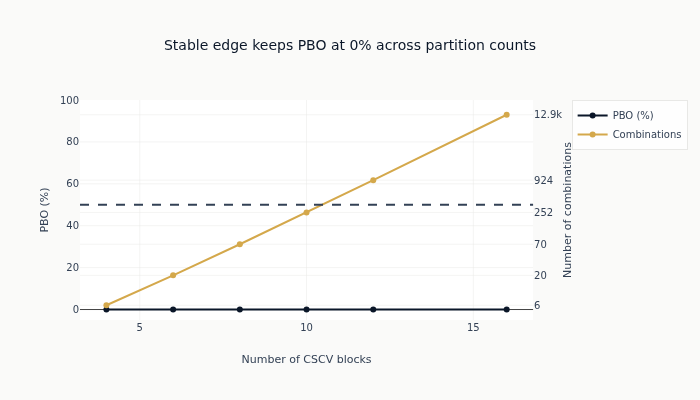

In [34]:
# Visualize PBO sensitivity to the CSCV partition count.
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=pbo_blocks_df["n_blocks"].to_list(),
        y=(pbo_blocks_df["pbo"] * 100).to_list(),
        name="PBO (%)",
        mode="lines+markers",
        line={"color": COLORS["blue"]},
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=pbo_blocks_df["n_blocks"].to_list(),
        y=pbo_blocks_df["n_combinations"].to_list(),
        name="Combinations",
        mode="lines+markers",
        line={"color": COLORS["amber"]},
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Stable edge keeps PBO at 0% across partition counts",
    xaxis_title="Number of CSCV blocks",
    height=400,
)
fig.add_hline(y=50, line_dash="dash", line_color=COLORS["neutral"], secondary_y=False)
fig.update_yaxes(title_text="PBO (%)", range=[-5, 100], secondary_y=False)
fig.update_yaxes(
    title_text="Number of combinations",
    type="log",
    tickmode="array",
    tickvals=pbo_blocks_df["n_combinations"].to_list(),
    ticktext=["6", "20", "70", "252", "924", "12.9k"],
    secondary_y=True,
)
fig.show()

### DSR and PBO answer different questions

DSR evaluates the selected Sharpe against a multiple-testing benchmark. PBO
evaluates whether IS selection is stable across complementary samples. The
return panel below gives each candidate a different block-specific edge with
zero average across blocks, creating temporal instability without inventing
independent IS/OOS score matrices. The computed diagnostics decide the outcome; the example
does not force either method to pass or fail.

In [35]:
def simulate_regime_sensitive_returns(
    n_observations: int,
    n_strategies: int,
    n_blocks: int,
    seed: int,
    block_sharpe_scale: float = 3.0,
    daily_vol: float = 0.01,
) -> np.ndarray:
    """Simulate candidates whose expected returns vary across time blocks."""
    rng = np.random.default_rng(seed)
    block_sharpes = rng.normal(0, block_sharpe_scale, (n_blocks, n_strategies))
    block_sharpes -= block_sharpes.mean(axis=0, keepdims=True)
    result = np.empty((n_observations, n_strategies))
    for indices, block_sr in zip(
        np.array_split(np.arange(n_observations), n_blocks), block_sharpes
    ):
        daily_means = block_sr * daily_vol / np.sqrt(252)
        result[indices] = rng.normal(daily_means, daily_vol, (len(indices), n_strategies))
    return result

In [36]:
true_n_trials = 200
reported_n_trials = 10
overfit_returns = simulate_regime_sensitive_returns(
    n_observations=PBO_OBSERVATIONS,
    n_strategies=true_n_trials,
    n_blocks=N_BLOCKS,
    seed=123,
)
is_perf_overfit, oos_perf_overfit = cscv_sharpe_matrices(overfit_returns, N_BLOCKS)
best_idx = int(np.argmax(is_perf_overfit[0]))
best_is_sharpe = float(is_perf_overfit[0, best_idx])
best_oos_sharpe = float(oos_perf_overfit[0, best_idx])
first_blocks = np.array_split(overfit_returns, N_BLOCKS, axis=0)[: N_BLOCKS // 2]
first_is_returns = np.concatenate(first_blocks)[:, best_idx]
is_skewness = float(stats.skew(first_is_returns))
is_kurtosis = float(stats.kurtosis(first_is_returns) + 3)
is_sharpe_variance = float(np.var(is_perf_overfit[0], ddof=1))

In [37]:
# Compute DSR with under-reported and true trial counts, compare to PBO
dsr_underreported = deflated_sharpe_ratio(
    observed_sharpe=best_is_sharpe,
    skewness=is_skewness,
    kurtosis=is_kurtosis,
    n_samples=len(first_is_returns),
    n_trials=reported_n_trials,
    variance_trials=is_sharpe_variance,
    return_format="probability",
)

dsr_true = deflated_sharpe_ratio(
    observed_sharpe=best_is_sharpe,
    skewness=is_skewness,
    kurtosis=is_kurtosis,
    n_samples=len(first_is_returns),
    n_trials=true_n_trials,
    variance_trials=is_sharpe_variance,
    return_format="probability",
)

pbo_overfit = compute_pbo(
    is_performance=is_perf_overfit,
    oos_performance=oos_perf_overfit,
)
pbo_overfit_dict = pbo_overfit.to_dict() if hasattr(pbo_overfit, "to_dict") else pbo_overfit

In [38]:
print("\n" + "=" * 70)
print("CASE STUDY: TRIAL CORRECTION AND TEMPORAL STABILITY")
print("=" * 70)
print(f"\nTrue trials tested: {true_n_trials}")
print(f"Reported trials: {reported_n_trials}")
print(f"\nBest strategy IS Sharpe: {best_is_sharpe:.2f}")
print(f"Best strategy OOS Sharpe: {best_oos_sharpe:.2f}")
print(f"Performance degradation: {(best_is_sharpe - best_oos_sharpe):.2f}")

_ur_verdict = "passes" if dsr_underreported >= DSR_PASS_THRESHOLD else "fails"
_true_verdict = "passes" if dsr_true >= DSR_PASS_THRESHOLD else "fails"
_pbo_verdict = (
    "flags instability" if pbo_overfit_dict["pbo"] > PBO_REJECT_THRESHOLD else "does not flag"
)

print("\n--- DETECTION RESULTS ---")
print(f"DSR (under-reported trials={reported_n_trials}): {dsr_underreported:.1%}, {_ur_verdict}")
print(f"DSR (true trial count={true_n_trials}): {dsr_true:.1%}, {_true_verdict}")
print(f"PBO (all CSCV splits): {pbo_overfit_dict['pbo']:.1%}, {_pbo_verdict}")
print("\nDSR tests the selected split against its trial benchmark.")
print("PBO tests whether selection persists across complementary time blocks.")


CASE STUDY: TRIAL CORRECTION AND TEMPORAL STABILITY

True trials tested: 200
Reported trials: 10

Best strategy IS Sharpe: 2.37
Best strategy OOS Sharpe: -2.58
Performance degradation: 4.95

--- DETECTION RESULTS ---
DSR (under-reported trials=10): 99.4%, passes
DSR (true trial count=200): 12.5%, fails
PBO (all CSCV splits): 100.0%, flags instability

DSR tests the selected split against its trial benchmark.
PBO tests whether selection persists across complementary time blocks.


### Which of the three to reach for

| Method | Best For | Measures |
|--------|----------|----------|
| **DSR** | Known trial count and dispersion | Evidence above a selection benchmark |
| **PBO** | CSCV strategy selection | How often the in-sample choice ranks below median out of sample |
| **RAS** | Candidate performance matrix | Complexity-based lower performance bound |

**Decision Framework**:

1. Use DSR when the trial count and cross-trial dispersion are known.
2. Use PBO when complementary CSCV performance is available.
3. Use RAS when the candidate return or prediction class is available.
4. Set decision thresholds before looking at the diagnostic results.
5. Treat these diagnostics as complementary evidence, not deployment rules.

**Recommendation**: Use multiple methods. If any raises red flags, investigate further.

## Key takeaways

### What to take away

1. **Selection bias is measurable**: the largest null Sharpe rises with the number of trials
2. **Non-normality is conditional**: Skew and kurtosis change the DSR denominator.
   When the observed Sharpe is below its benchmark, a larger denominator moves the
   negative z-score toward zero and can raise the probability slightly; above the
   benchmark, the direction reverses.
3. **DSR provides a calibrated statistic**: Its benchmark includes the selection process
4. **PBO uses CSCV**: Every IS block assignment is paired with its OOS complement
5. **Combine methods**: DSR, PBO, and RAS for comprehensive overfitting detection

### What to do

1. **Always track trials**: Record every strategy variant tested
2. **Report DSR alongside raw Sharpe**: Disclose the full trial count
3. **Use realistic parameters**: Include non-normality in calculations
4. **Pre-register thresholds**: Choose decision criteria before inspecting results

### The checklist

- [ ] Count every strategy variant tested, including the ones abandoned early
- [ ] Measure the Sharpe variance across those variants rather than assuming one
- [ ] Measure the selected strategy's return skewness and kurtosis
- [ ] Compute the deflated Sharpe ratio with all of the above
- [ ] Compute PBO from complementary CSCV splits of the same return panel
- [ ] Compare the three corrections and investigate where they disagree
- [ ] Apply thresholds written down before any of this was computed

### Known limitations

- Every strategy in this notebook is a parametric draw. Real candidate strategies share data,
  features and signals, so their Sharpe ratios are correlated, and the effective number of
  independent trials is smaller than the count. Feeding the raw count to the correction
  over-deflates; feeding the effective number requires estimating it.
- The trial count is assumed known. In practice nobody records the variants abandoned after a
  glance, and section 8 shows what under-reporting does to the answer.
- The corrections take return moments as given. On a short record those moments are themselves
  estimated with wide error, which propagates into the deflated probability and is not shown.
- PBO assumes the blocks are exchangeable. A strategy whose edge genuinely decayed over the
  sample will be flagged as unstable, correctly by the statistic and misleadingly as overfitting.

In [39]:
# Summary
print("=" * 80)
print("OVERFITTING DETECTION SUMMARY")
print("=" * 80)

print("\n1. SELECTION BIAS DEMONSTRATION:")
print(f"   - Tested 100 null strategies, best had SR = {results['max_sharpe']:.2f}")
print("   - Every candidate was generated with zero expected return")

print("\n2. DSR DECAY WITH TRIALS:")
print(f"   - 1 trial: DSR = {dsr_df.row(0, named=True)['dsr_probability']:.1%}")
print(f"   - 100 trials: DSR = {dsr_df.row(5, named=True)['dsr_probability']:.1%}")
print(f"   - 500 trials: DSR = {dsr_df.row(7, named=True)['dsr_probability']:.1%}")

print("\n3. CASE STUDY RESULT:")
print(f"   - Best synthetic variant: SR = {best['observed_sharpe']:.2f}")
print(f"   - Without correction (PSR): {psr_best:.1%}")
print(f"   - With DSR correction: {dsr_best:.1%}")

print("\n4. DSR vs RAS:")
print(f"   - DSR adjusted Sharpe: {dsr_adjusted_sharpe:.3f}")
print(f"   - RAS adjusted Sharpe: {ras_adjusted:.3f}")

print("\n5. PBO ANALYSIS:")
print(f"   - Probability of Backtest Overfitting: {pbo_value:.1%}")
print("   - Computed from all complementary CSCV splits")

print("\n" + "=" * 80)

OVERFITTING DETECTION SUMMARY

1. SELECTION BIAS DEMONSTRATION:
   - Tested 100 null strategies, best had SR = 2.47
   - Every candidate was generated with zero expected return

2. DSR DECAY WITH TRIALS:
   - 1 trial: DSR = 97.7%
   - 100 trials: DSR = 18.4%
   - 500 trials: DSR = 6.7%

3. CASE STUDY RESULT:
   - Best synthetic variant: SR = 2.17
   - Without correction (PSR): 99.9%
   - With DSR correction: 78.2%

4. DSR vs RAS:
   - DSR adjusted Sharpe: 0.553
   - RAS adjusted Sharpe: 1.636

5. PBO ANALYSIS:
   - Probability of Backtest Overfitting: 0.0%
   - Computed from all complementary CSCV splits

